## Epoching of the Patient 1 data  
Split the edfs into 5 minute chunks. Each edf is 1-hour long. We choose 01.edf for the baseline data and 03.edf for the data with seizure.

In [5]:
import mne
import numpy as np

# 1. Define file paths (ensure these are in your working directory)
file_1 = "chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf"  # Baseline (0 seizures)
file_3 = "chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf"  # Seizure file (starts at 2996s)

# 2. Load the raw data into memory
# preload=True is required to perform math on the data later
raw_base = mne.io.read_raw_edf(file_1, preload=True)
raw_seiz = mne.io.read_raw_edf(file_3, preload=True)

# 3. Clean channel names (removes trailing dots or spaces)
raw_base.rename_channels(lambda x: x.strip('.'))
raw_seiz.rename_channels(lambda x: x.strip('.'))

# 4. Generate 5-second fixed-length event markers
# This tells MNE where to "cut" the data without any overlap
events_base = mne.make_fixed_length_events(raw_base, duration=5.0)
events_seiz = mne.make_fixed_length_events(raw_seiz, duration=5.0)

# 5. Create the 'Chops' (Epochs)
# tmin=0, tmax=5.0 creates exactly 5-second windows
epochs_base = mne.Epochs(raw_base, events_base, tmin=0, tmax=5.0, 
                         baseline=None, preload=True, verbose=False)

epochs_seiz = mne.Epochs(raw_seiz, events_seiz, tmin=0, tmax=5.0, 
                         baseline=None, preload=True, verbose=False)

# 6. Convert to Numpy arrays for feature extraction
# Shape will be: (Number of windows, 23 channels, 1281 samples)
data_base = epochs_base.get_data()
data_seiz = epochs_seiz.get_data()

print(f"Success! Baseline file divided into {data_base.shape[0]} windows.")
print(f"Seizure file divided into {data_seiz.shape[0]} windows.")
print(f"Samples per window (at 256Hz): {data_base.shape[2]}")

Extracting EDF parameters from /Users/anandm/sid/eeg_proj/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
Extracting EDF parameters from /Users/anandm/sid/eeg_proj/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_30770/655837815.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_base = mne.io.read_raw_edf(file_1, preload=True)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_30770/655837815.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_seiz = mne.io.read_raw_edf(file_3, preload=True)


Success! Baseline file divided into 719 windows.
Seizure file divided into 719 windows.
Samples per window (at 256Hz): 1281


In [8]:
!pip install antropy

In [18]:
import numpy as np
from scipy.signal import welch
from antropy import perm_entropy

# Left↔Right homologous bipolar pairs (0-based indices) based on EDF channel list
# Left (1–8) pairs with Right (9–16 / 13–16) as appropriate:
PAIRS_LR = [
    (0, 12),  # ch1  FP1-F7  ↔ ch13 FP2-F8
    (1, 13),  # ch2  F7-T7   ↔ ch14 F8-T8
    (2, 14),  # ch3  T7-P7   ↔ ch15 T8-P8
    (3, 15),  # ch4  P7-O1   ↔ ch16 P8-O2
    (4, 8),   # ch5  FP1-F3  ↔ ch9  FP2-F4
    (5, 9),   # ch6  F3-C3   ↔ ch10 F4-C4
    (6, 10),  # ch7  C3-P3   ↔ ch11 C4-P4
    (7, 11),  # ch8  P3-O1   ↔ ch12 P4-O2
]

def get_advanced_state_features(epoch_data, sfreq=256):
    """
    Transforms 5-second EEG windows into a 6D state-space coordinate:
    1. Theta/Alpha Ratio
    2. Permutation Entropy
    3. Hemispheric Synchronization
    4. Line Length (Spikiness)
    5. RMS Amplitude (Power)
    6. Spectral Edge Frequency 95%
    """
    features = []
    eps = 1e-10

    for window in epoch_data:
        # Use primary 18 channels to avoid redundant data
        X = window[0:18, :]

        # 1) SPECTRAL RATIO: Energy-based Theta/Alpha ratio
        freqs, psd = welch(X, sfreq, nperseg=sfreq * 2)
        th_mask = (freqs >= 4) & (freqs < 8)
        al_mask = (freqs >= 8) & (freqs < 13)
        theta = np.trapezoid(psd[:, th_mask], freqs[th_mask], axis=1).mean()
        alpha = np.trapezoid(psd[:, al_mask], freqs[al_mask], axis=1).mean()
        ta_ratio = theta / (alpha + eps)

        # 2) COMPLEXITY: Permutation Entropy
        complexity = np.mean([perm_entropy(ch, order=4, delay=1, normalize=True) for ch in X])

        # 3) SYNCHRONIZATION: Mean Correlation over homologous pairs
        sync_scores = [np.corrcoef(window[li], window[ri])[0, 1] for li, ri in PAIRS_LR]
        avg_sync = np.nanmean(sync_scores)

        # 4) LINE LENGTH: Total vertical distance (measures 'spikiness')
        line_length = np.mean(np.sum(np.abs(np.diff(X, axis=1)), axis=1))

        # 5) RMS AMPLITUDE: Root Mean Square (measures signal 'loudness')
        rms = np.mean(np.sqrt(np.mean(X**2, axis=1)))

        # 6) SPECTRAL EDGE FREQUENCY (95%): Frequency below which 95% power sits
        df = np.diff(freqs)
        df = np.r_[df, df[-1]]                 # match length to freqs
        power_bins = psd * df                  # convert PSD (per Hz) -> power per bin
        cumulative_power = np.cumsum(power_bins, axis=1)
        total_power = cumulative_power[:, -1]
        sef_indices = np.argmax(cumulative_power >= 0.95 * total_power[:, None], axis=1)
        avg_sef95 = freqs[sef_indices].mean()


        features.append([ta_ratio, complexity, avg_sync, line_length, rms, avg_sef95])

    return np.array(features)

# Apply the advanced extraction
print("Mapping Advanced State Space...")
feat_base = get_advanced_state_features(data_base)
feat_seiz = get_advanced_state_features(data_seiz)

print(f"Done. Each window is now a {feat_base.shape[1]}D coordinate.")
print("feat_base shape:", feat_base.shape)
print("feat_seiz shape:", feat_seiz.shape)

Mapping Advanced State Space...
Done. Each window is now a 6D coordinate.
feat_base shape: (719, 6)
feat_seiz shape: (719, 6)


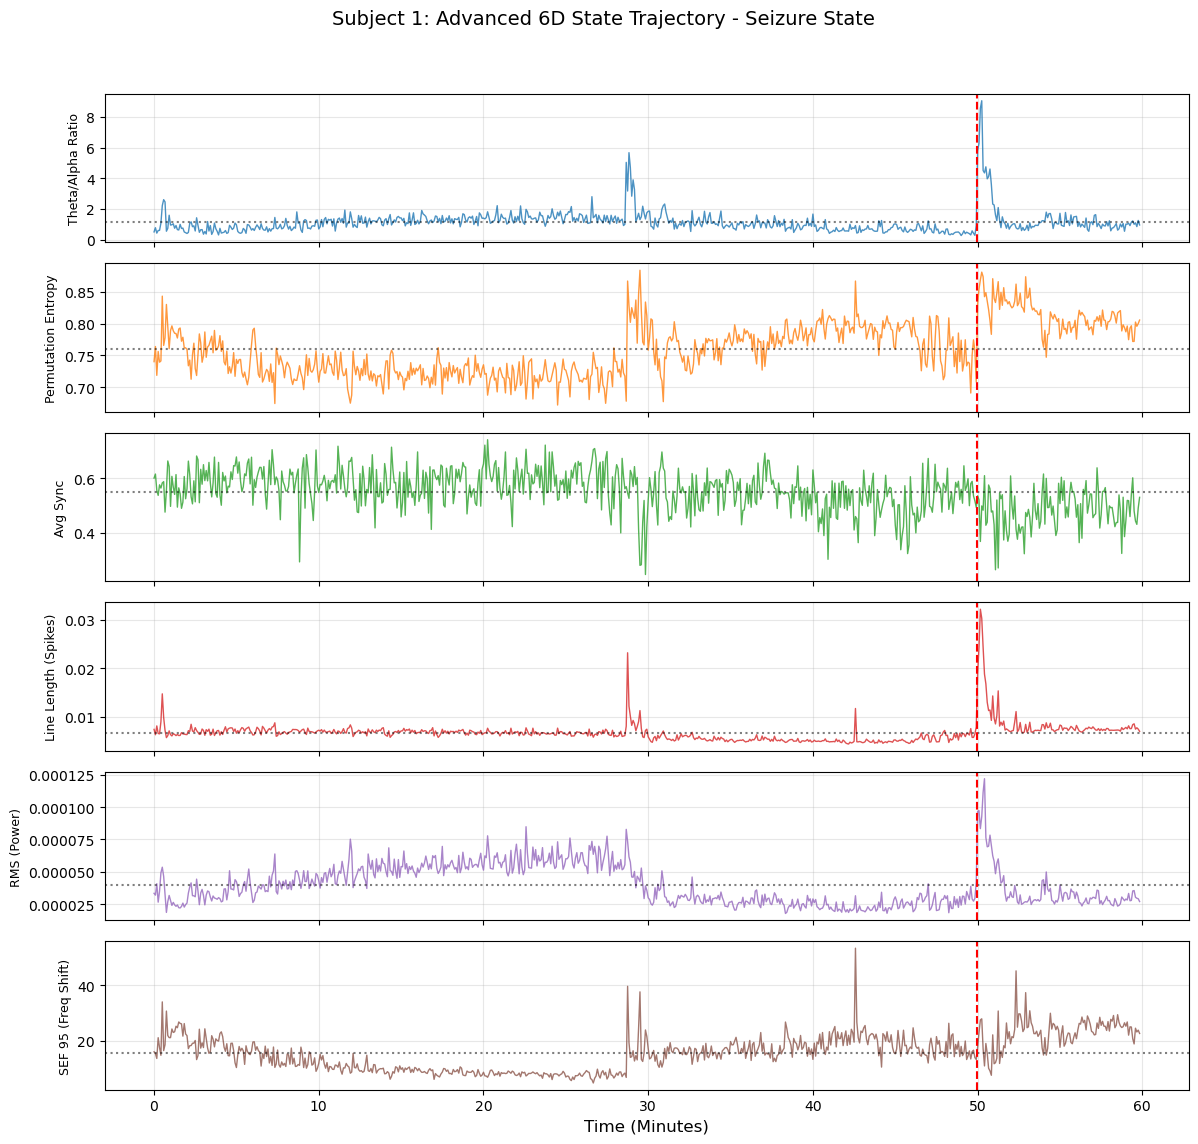

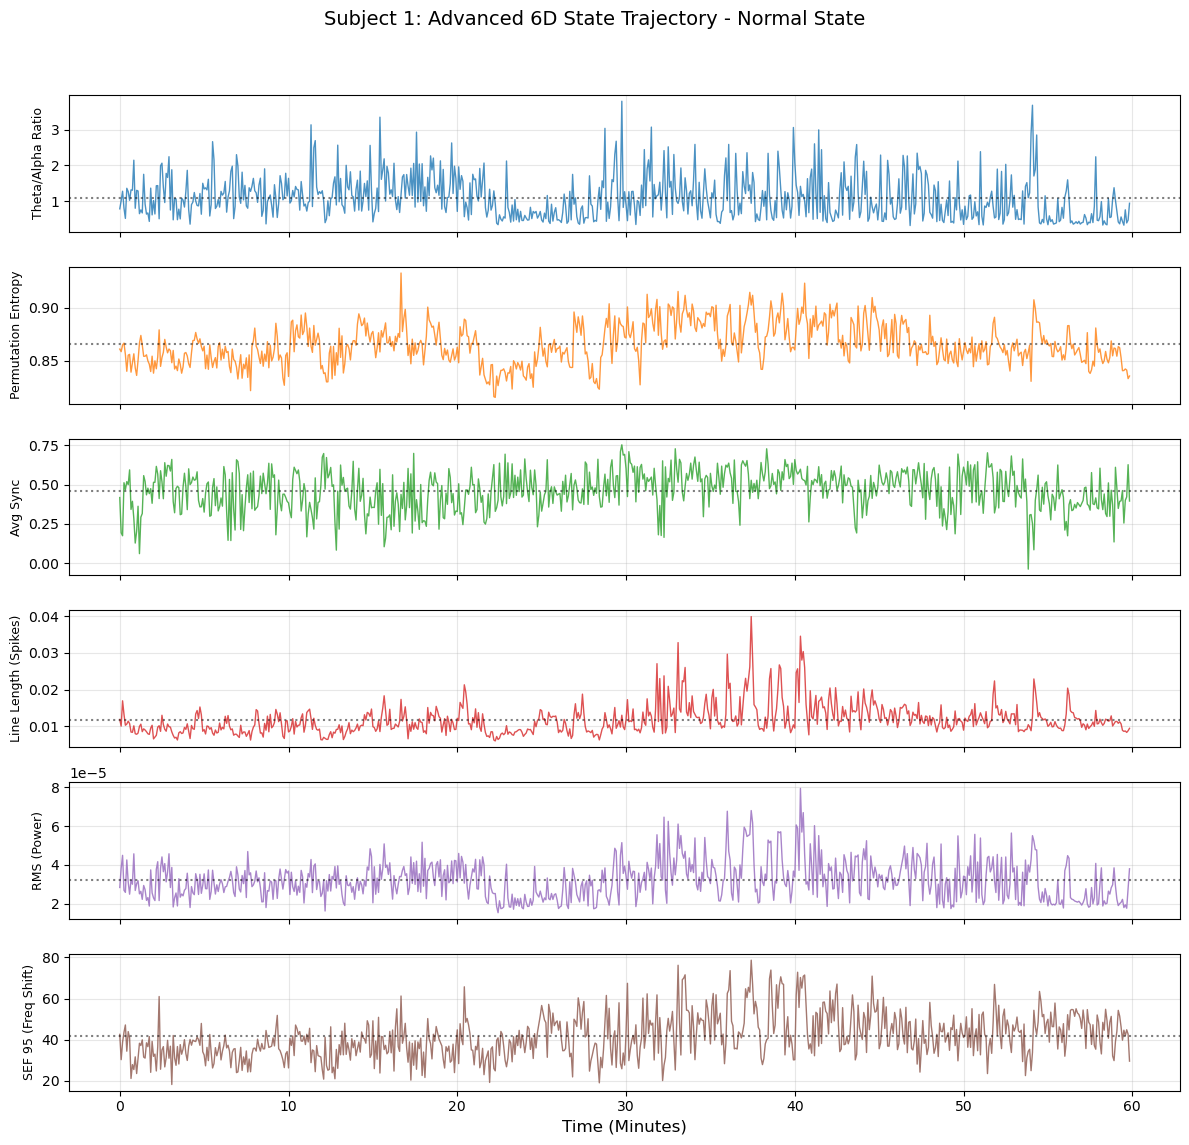

In [21]:
import matplotlib.pyplot as plt

def plot_advanced_state_features(features, title, seizure_time=None):
    """
    Plots the 6 extracted EEG features over time to visualize state transitions.
    """
    n_features = features.shape[1]
    fig, ax = plt.subplots(n_features, 1, figsize=(12, 2 * n_features), sharex=True)
    
    # Convert window indices to minutes (5s windows)
    time_axis = np.arange(len(features)) * 5 / 60  
    
    labels = [
        'Theta/Alpha Ratio', 
        'Permutation Entropy', 
        'Avg Sync', 
        'Line Length (Spikes)', 
        'RMS (Power)', 
        'SEF 95 (Freq Shift)'
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i in range(n_features):
        ax[i].plot(time_axis, features[:, i], color=colors[i], alpha=0.8, linewidth=1)
        ax[i].set_ylabel(labels[i], fontsize=9)
        ax[i].grid(True, alpha=0.3)
        
        # Add a horizontal mean line for the entire file to help see "drifts"
        mean_val = np.mean(features[:, i])
        ax[i].axhline(y=mean_val, color='black', linestyle=':', alpha=0.5)
        
        if seizure_time:
            # Mark the clinical seizure onset
            ax[i].axvline(x=seizure_time/60, color='red', linestyle='--', label='Seizure Onset')

    ax[-1].set_xlabel('Time (Minutes)', fontsize=12)
    plt.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot the Advanced Seizure File Trajectory (chb01_03)
plot_advanced_state_features(feat_seiz, "Subject 1: Advanced 6D State Trajectory - Seizure State", seizure_time=2996)
# Plot the Advanced Seizure File Trajectory (chb01_01)
plot_advanced_state_features(feat_base, "Subject 1: Advanced 6D State Trajectory - Normal State")

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Stack the features vertically (Baseline first, then Seizure file)
# Total shape will be (1438 windows, 6 features)
feat_combined = np.vstack((feat_base, feat_seiz))

# 2. Standardize the data 
# This ensures a feature with large numbers (like SEF95) doesn't drown out a small one (like Entropy)
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(feat_combined)

# 3. PCA: Reduce to 3D for the HMM
# While we plot in 2D, HMMs often perform better with 3 dimensions of 'Signal'
pca = PCA(n_components=3)
obs_for_hmm = pca.fit_transform(feat_scaled)

print(f"Combined Dataset Shape: {obs_for_hmm.shape}")
print(f"Variance captured by 3 PCs: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

Combined Dataset Shape: (1438, 3)
Variance captured by 3 PCs: 90.44%


In [24]:
!pip install hmmlearn

In [25]:
from hmmlearn import hmm

# 1. Initialize the Gaussian HMM
# We choose 3 states: Stable (0), Pre-Ictal (1), and Ictal (2)
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)

# 2. Fit the model to 3D PCA coordinates
# The model learns the 'clusters' and the 'transition rules'
model.fit(obs_for_hmm)

# 3. Predict the hidden states for the entire sequence
hidden_states = model.predict(obs_for_hmm)

print("HMM Training Complete.")
print(f"Unique states identified: {np.unique(hidden_states)}")

HMM Training Complete.
Unique states identified: [0 1 2]


In [26]:
# Check the mean of the features for each state to identify them
for i in range(3):
    mask = (hidden_states == i)
    # Using the 4th feature (Index 3) which is Line Length/Spikiness
    mean_spikiness = np.mean(feat_combined[mask, 3])
    print(f"State {i} Average Spikiness: {mean_spikiness:.4f}")

# Logic: The state with the highest spikiness is almost always the 'Ictal/Seizure' state.
# The state that dominates the first 60 minutes is the 'Stable' state.

State 0 Average Spikiness: 0.0062
State 1 Average Spikiness: 0.0062
State 2 Average Spikiness: 0.0113


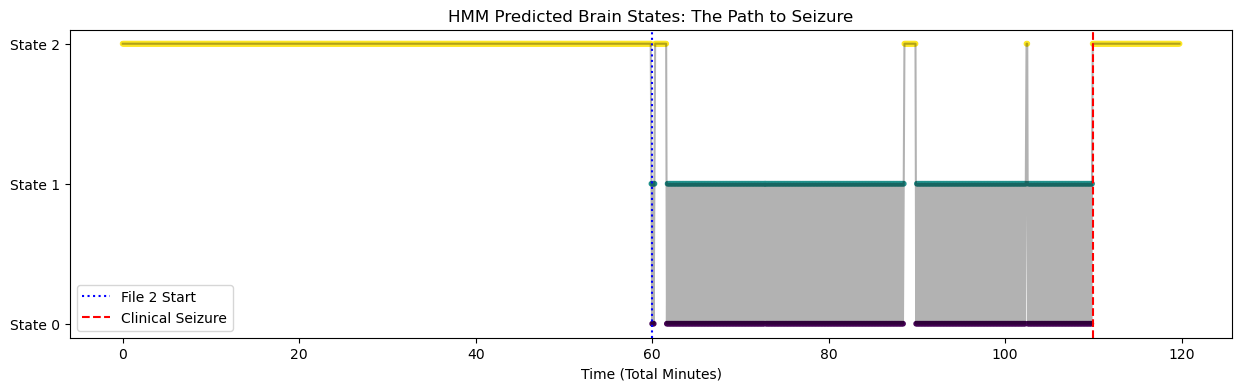

In [27]:
plt.figure(figsize=(15, 4))
time_axis = np.arange(len(hidden_states)) * 5 / 60  # Minutes

# Plot the state sequence
plt.plot(time_axis, hidden_states, color='black', alpha=0.3)
plt.scatter(time_axis, hidden_states, c=hidden_states, cmap='viridis', s=10)

# Mark the file boundary and clinical seizure
plt.axvline(x=60, color='blue', linestyle=':', label='File 2 Start')
plt.axvline(x=60 + (2996/60), color='red', linestyle='--', label='Clinical Seizure')

plt.yticks([0, 1, 2], ['State 0', 'State 1', 'State 2'])
plt.xlabel('Time (Total Minutes)')
plt.title('HMM Predicted Brain States: The Path to Seizure')
plt.legend()
plt.show()

In [28]:
import pandas as pd

# Get the transition matrix from the trained model
trans_matrix = model.transmat_

# Create a readable table
state_names = ['State 0', 'State 1', 'State 2']
df_trans = pd.DataFrame(trans_matrix, columns=state_names, index=state_names)

print("Transition Probability Matrix:")
print(df_trans.round(4))

Transition Probability Matrix:
         State 0  State 1  State 2
State 0   0.0016   0.9984   0.0000
State 1   0.9753   0.0107   0.0140
State 2   0.0034   0.0012   0.9954
